# Grammar of Graphics in Python

**Instructor:** Amera Al-Amery  
**Course:** Data Visualization  

This notebook introduces core data-visualization ideas in Python using:

- `pandas` for data handling
- `matplotlib` for plotting control
- `seaborn` for statistical visualization

We will cover:

1. Data
2. Aesthetic mappings
3. Geometries
4. Faceting
5. Statistical layers
6. Themes and style
7. Coordinate control
8. Log scales and annotations


## Setup

In [2]:
# Run this once if needed:
# !pip install pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

---
## Example 1: Iris Dataset

In [3]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### 1. Data + Aesthetic Mapping

Map `sepal_length` to the x-axis and `sepal_width` to the y-axis.

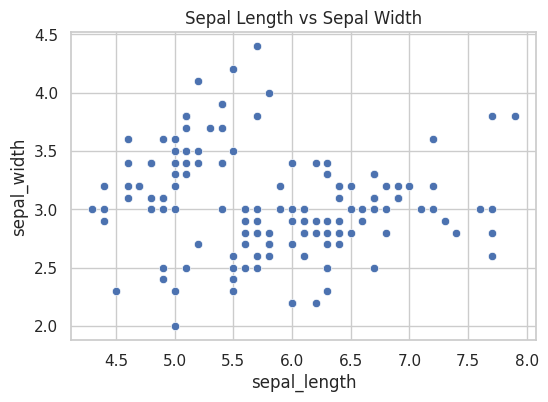

In [5]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width')
plt.title('Sepal Length vs Sepal Width')
plt.show()

### 2. Add Color as an Aesthetic

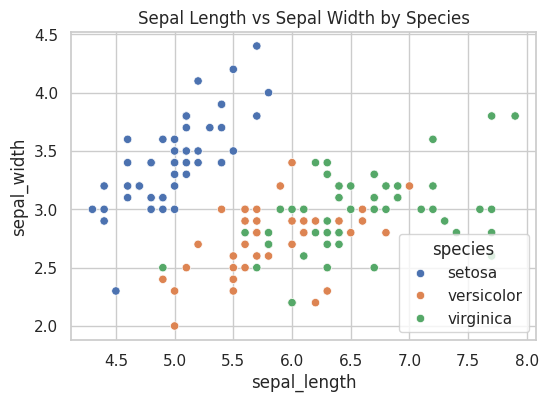

In [6]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width', hue='species')
plt.title('Sepal Length vs Sepal Width by Species')
plt.show()

### 3. Faceting

Faceting creates small plots for each category.

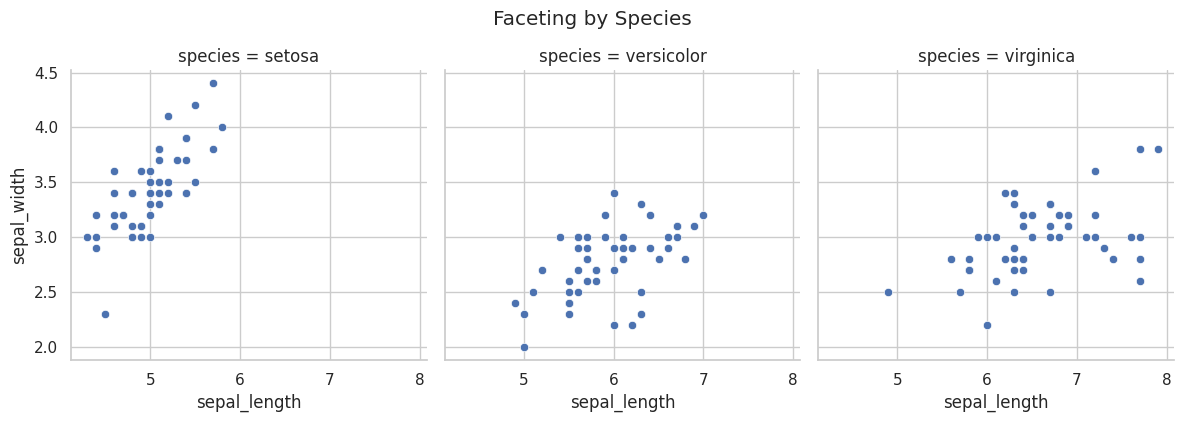

In [7]:
g = sns.FacetGrid(iris, col='species', height=4, aspect=1)
g.map_dataframe(sns.scatterplot, x='sepal_length', y='sepal_width')
g.fig.suptitle('Faceting by Species', y=1.05)
plt.show()

### 4. Add a Statistical Layer

Use regression lines to show trends.

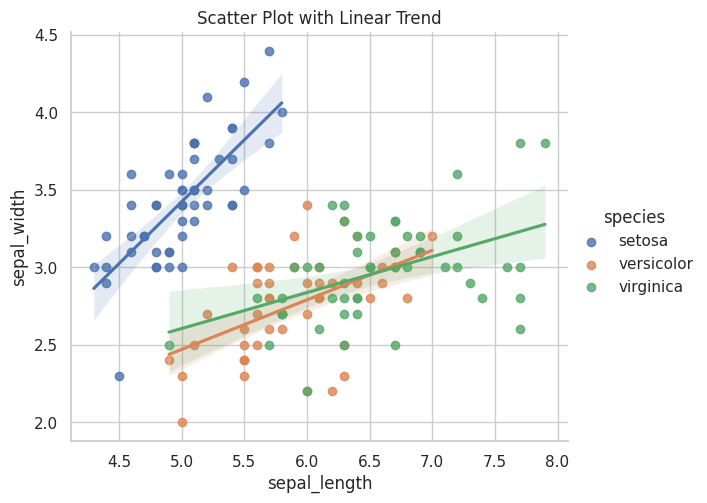

In [8]:
sns.lmplot(data=iris, x='sepal_length', y='sepal_width', hue='species', height=5, aspect=1.2)
plt.title('Scatter Plot with Linear Trend')
plt.show()

### 5. Theme / Style

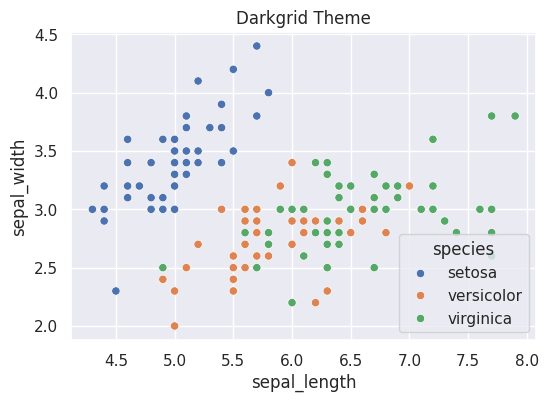

In [9]:
sns.set_style('darkgrid')

plt.figure(figsize=(6,4))
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width', hue='species')
plt.title('Darkgrid Theme')
plt.show()

# return to whitegrid for the rest of the notebook
sns.set_style('whitegrid')

### 6. Coordinate Control

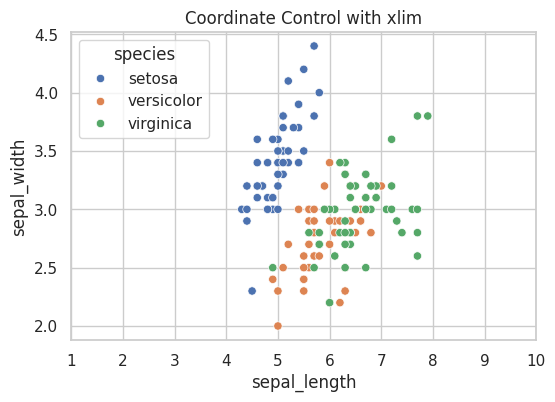

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width', hue='species')
plt.xlim(1, 10)
plt.title('Coordinate Control with xlim')
plt.show()

## Confounder Impact 

## Using correlation

In [19]:
# Overall correlation
print("Overall:", iris['sepal_length'].corr(iris['sepal_width']))

# By species
print("\nBy species:")
print(iris.groupby('species')[['sepal_length','sepal_width']].corr())

Overall: -0.11756978413300208

By species:
                         sepal_length  sepal_width
species                                           
setosa     sepal_length      1.000000     0.742547
           sepal_width       0.742547     1.000000
versicolor sepal_length      1.000000     0.525911
           sepal_width       0.525911     1.000000
virginica  sepal_length      1.000000     0.457228
           sepal_width       0.457228     1.000000


## Model WITHOUT species (simple LM)

In [29]:
from sklearn.linear_model import LinearRegression

X = iris[['sepal_length']]
y = iris['sepal_width']

model1 = LinearRegression().fit(X, y)
print("Intercept:", model1.intercept_)

print("Coefficients:", model1.coef_)
print("Features:", X.columns)

sepal_width=3.4-0.06*sepal_length 

Intercept: 3.418946836103816
Coefficients: [-0.0618848]
Features: Index(['sepal_length'], dtype='object')


## Model WITH species

In [27]:
import pandas as pd

X2 = pd.get_dummies(iris[['sepal_length', 'species']], drop_first=True)
y2 = iris['sepal_width']

model2 = LinearRegression().fit(X2, y2)
print("Intercept:", model2.intercept_)
print("Coefficients:", model2.coef_)
print("Features:", X2.columns)

sepal_width=1.6+0.34*sepal_length-0.9*species_versicolor-1.00751035*species_virginica


Intercept: 1.6765001103803754
Coefficients: [ 0.34988012 -0.98338851 -1.00751035]
Features: Index(['sepal_length', 'species_versicolor', 'species_virginica'], dtype='object')


## Another way to build the Model 

In [32]:
import statsmodels.formula.api as smf

model1 = smf.ols("sepal_width ~ sepal_length", data=iris).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:            sepal_width   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     2.074
Date:                Mon, 30 Mar 2026   Prob (F-statistic):              0.152
Time:                        13:29:40   Log-Likelihood:                -86.732
No. Observations:                 150   AIC:                             177.5
Df Residuals:                     148   BIC:                             183.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.4189      0.254     13.484   

In [33]:
model2 = smf.ols("sepal_width ~ sepal_length + species", data=iris).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            sepal_width   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     64.32
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.46e-26
Time:                        13:29:44   Log-Likelihood:                -24.609
No. Observations:                 150   AIC:                             57.22
Df Residuals:                     146   BIC:                             69.26
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.67

---
## Example 2: Murders Dataset

This example uses a dataset similar to the `murders` dataset from `dslabs` in R.

Update the file path if needed.

In [12]:
# Replace the path if your CSV is stored elsewhere
murders = pd.read_csv('/kaggle/input/datasets/eimieimieimi86/murders/murders.csv')
murders.head()

,state,abb,region,population,total
0,Alabama,AL,South,4779736,135
1,Alaska,AK,West,710231,19
2,Arizona,AZ,West,6392017,232
3,Arkansas,AR,South,2915918,93
4,California,CA,West,37253956,1257


In [13]:
murders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   state       51 non-null     object
 1   abb         51 non-null     object
 2   region      51 non-null     object
 3   population  51 non-null     int64 
 4   total       51 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.1+ KB


In [14]:
murders['pop_m'] = murders['population'] / 1_000_000
murders[['state', 'abb', 'region', 'population', 'total', 'pop_m']].head()

,state,abb,region,population,total,pop_m
0,Alabama,AL,South,4779736,135,4.779736
1,Alaska,AK,West,710231,19,0.710231
2,Arizona,AZ,West,6392017,232,6.392017
3,Arkansas,AR,South,2915918,93,2.915918
4,California,CA,West,37253956,1257,37.253956


### 1. Basic Scatter Plot

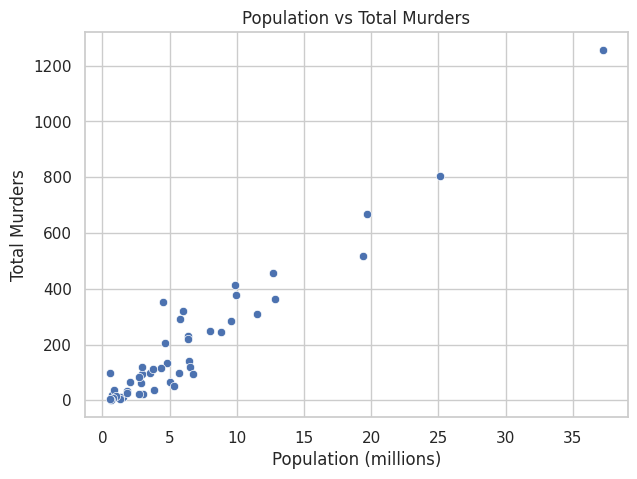

In [15]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=murders, x='pop_m', y='total')
plt.xlabel('Population (millions)')
plt.ylabel('Total Murders')
plt.title('Population vs Total Murders')
plt.show()

### 2. Color by Region

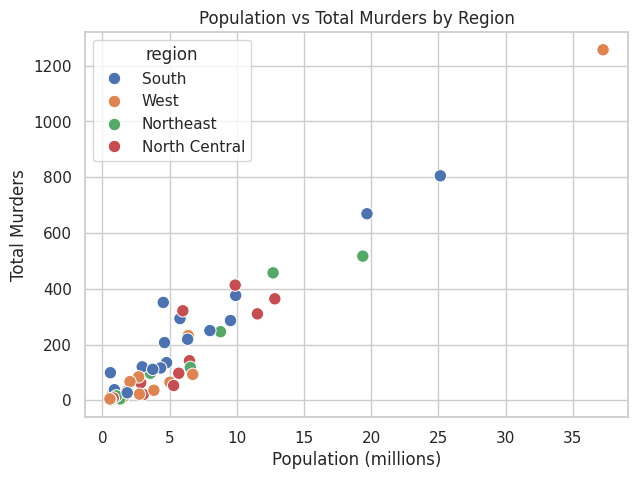

In [16]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=murders, x='pop_m', y='total', hue='region', s=80)
plt.xlabel('Population (millions)')
plt.ylabel('Total Murders')
plt.title('Population vs Total Murders by Region')
plt.show()

### 3. Add Text Labels

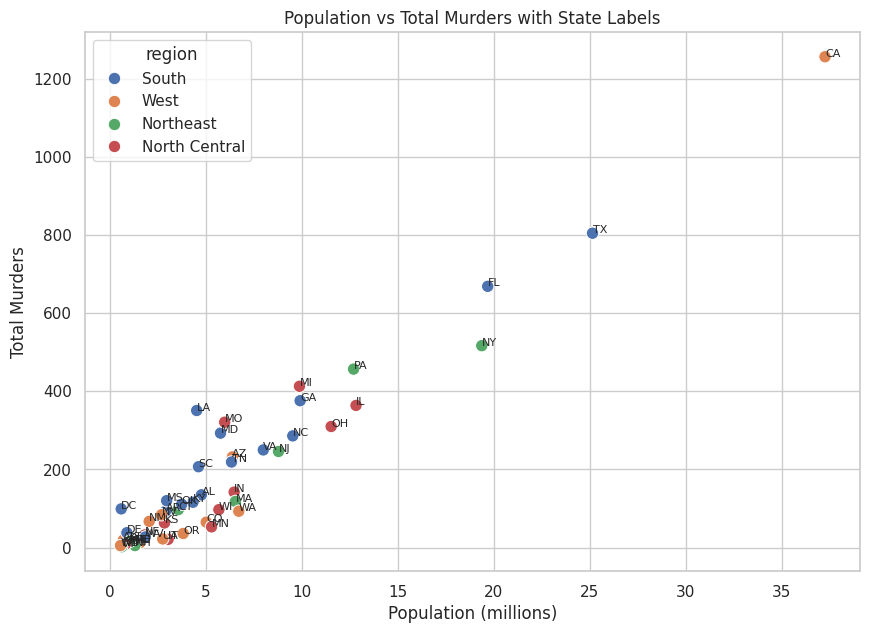

In [17]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=murders, x='pop_m', y='total', hue='region', s=80)

for _, row in murders.iterrows():
    plt.text(row['pop_m'], row['total'], row['abb'], fontsize=8)

plt.xlabel('Population (millions)')
plt.ylabel('Total Murders')
plt.title('Population vs Total Murders with State Labels')
plt.show()

### 4. Log Scales

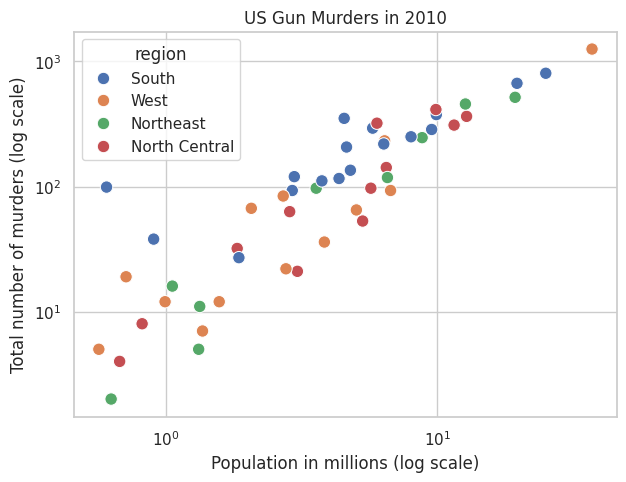

In [18]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=murders, x='pop_m', y='total', hue='region', s=80)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Population in millions (log scale)')
plt.ylabel('Total number of murders (log scale)')
plt.title('US Gun Murders in 2010')
plt.show()

### 5. Reference Line

Compute the national average murder rate and draw it as a dashed reference line.

### 6. Final Polished Plot

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=murders, x='pop_m', y='total', hue='region', s=90)

for _, row in murders.iterrows():
    plt.text(row['pop_m'], row['total'], row['abb'], fontsize=8)

plt.xscale('log')
plt.yscale('log')

x = np.linspace(murders['pop_m'].min(), murders['pop_m'].max(), 200)
y = r * x
plt.plot(x, y, linestyle='--', label='Average murder rate')

plt.xlabel('Population in millions (log scale)')
plt.ylabel('Total number of murders (log scale)')
plt.title('US Gun Murders in 2010')
plt.legend()
plt.show()

---
## Summary

In this notebook, you practiced:

1. Creating scatter plots with `seaborn`
2. Mapping variables to color using `hue`
3. Building faceted plots with `FacetGrid`
4. Adding statistical layers with `lmplot`
5. Changing themes and styles
6. Controlling axes and coordinates
7. Applying log scales
8. Adding labels and reference lines

This gives students a Python-based introduction to visualization concepts similar to those taught with `ggplot2` in R.